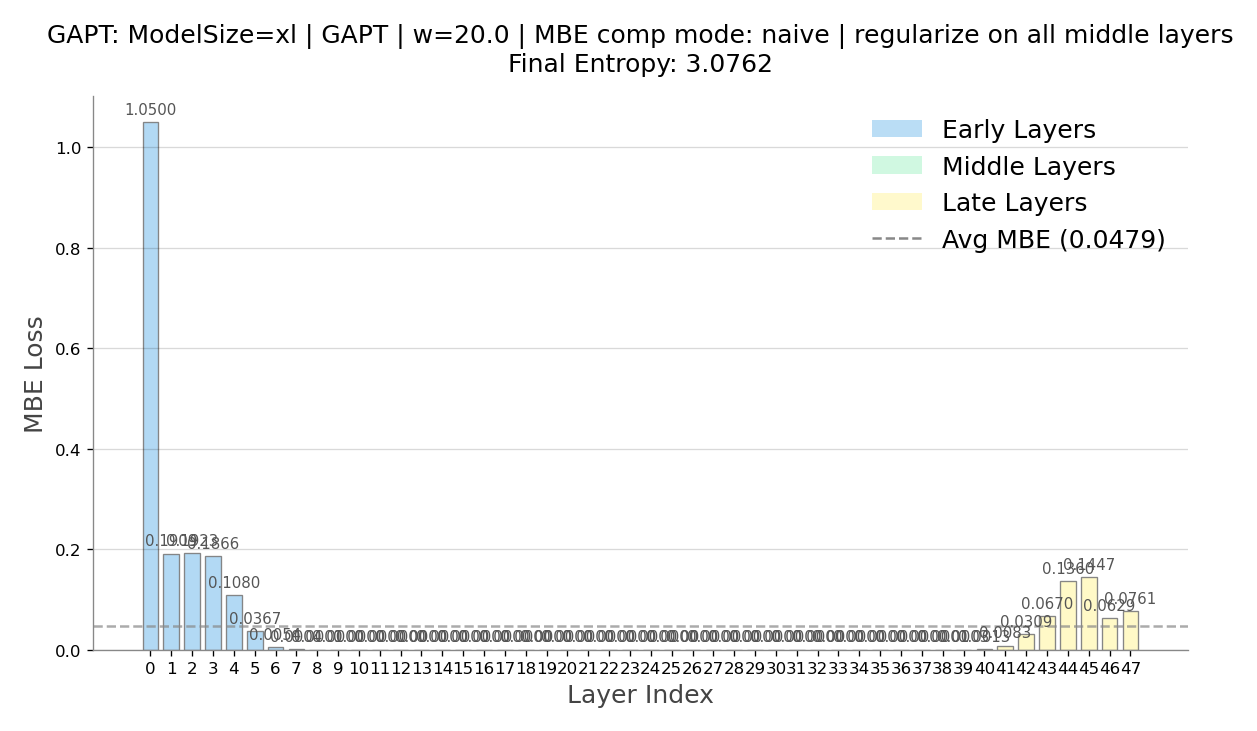

In [13]:
# Analysis on log runs 
from src.utils import *

# ----- IBLM ----- 
log_path = "logs/iblm-gpt2-xl-naive.txt"
# log_path = "logs/fineweb10B-gpt2-xl-20k.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])

# --- visualize dynamics ---
frames = []
for i in range(len(loss_record["entropy"])):
    if i % 1 == 0: # Optional: skip frames for speed
        print(f"Rendering frame {i}/{len(loss_record['entropy'])}", end='\r')
        frames.append(create_training_frame(i, loss_record, run_info=run_info, n_layer=n_layer))

frames[0].save(
    f"mbe_dynamics_{run_info}.gif",
    save_all=True,
    append_images=frames[1:],
    duration=100, # ms per frame
    loop=0
)

# --- visualize final losses ---
visualize_final_losses(loss_record, run_info=run_info, n_layer=n_layer)

In [15]:
import numpy as np
text = "mbe_0 loss: 0.8363 mbe_1 loss: 0.5568 mbe_2 loss: 0.0279 mbe_3 loss: 0.3661 mbe_4 loss: 0.0086 mbe_5 loss: 0.2349 mbe_6 loss: 0.0000 mbe_7 loss: 0.0020 mbe_8 loss: 0.0233 mbe_9 loss: 0.0086 mbe_10 loss: 0.0599 mbe_11 loss: 0.0307 mbe_12 loss: 0.0185 mbe_13 loss: 0.0055 mbe_14 loss: 0.0001 mbe_15 loss: 0.0000 mbe_16 loss: 0.0000 mbe_17 loss: 0.0000 mbe_18 loss: 0.0000 mbe_19 loss: 0.0000 mbe_20 loss: 0.0000 mbe_21 loss: 0.0000 mbe_22 loss: 0.0000 mbe_23 loss: 0.0000 mbe_24 loss: 0.0000 mbe_25 loss: 0.0000 mbe_26 loss: 0.0000 mbe_27 loss: 0.0000 mbe_28 loss: 0.0048 mbe_29 loss: 0.0067 mbe_30 loss: 0.0002 mbe_31 loss: 0.0667 mbe_32 loss: 0.0002 mbe_33 loss: 0.0148 mbe_34 loss: 0.0474 mbe_35 loss: 0.2631 mbe_36 loss: 0.2086 mbe_37 loss: 0.1727 mbe_38 loss: 0.1539 mbe_39 loss: 0.1489 mbe_40 loss: 0.1417 mbe_41 loss: 0.1016 mbe_42 loss: 0.1209 mbe_43 loss: 0.0231 mbe_44 loss: 0.0949 mbe_45 loss: 0.0609 mbe_46 loss: 0.0566 mbe_47 loss: 0.0640"
# help extract list of mbe, then compute mean of them

# Extract all float numbers after each "loss:" in the text string
import re
mbe_losses = [float(x) for x in re.findall(r'loss: ([0-9.]+)', text)]

# Compute mean
mean_mbe = np.mean(mbe_losses)
print(mean_mbe)

min_mbe = np.min(mbe_losses)
min_mbe

0.08189375


0.0

                   Two-Phase MBE Analysis                   

🔀 Transition Point: step 2,500 (MBE = 0.2495)

📉 SEPARATION PHASE (MBE decreasing)
   Steps:    0 → 2,500
   Duration: 2,500 steps (12.5% of training)
   MBE:      2.0156 → 0.2495
   Change:   -1.7661 (-87.62%)

📈 ENTANGLEMENT PHASE (MBE increasing)
   Steps:    2,500 → 20,000
   Duration: 17,500 steps (87.5% of training)
   MBE:      0.2495 → 0.4552
   Change:   0.2057 (+82.45%)


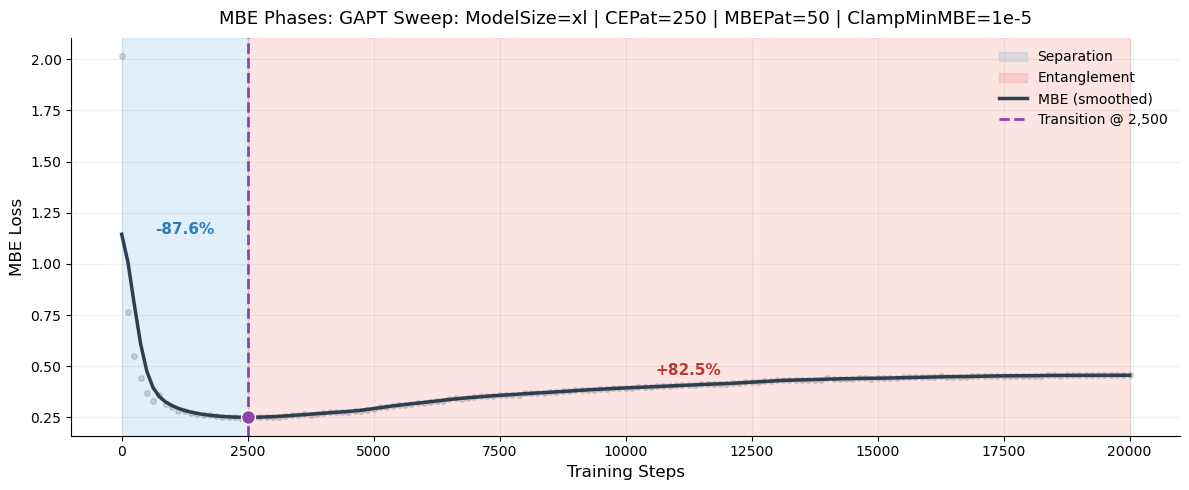

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def analyze_two_phase_transition(loss_record, val_interval=125, smooth_sigma=2):
    """
    Find the single separation→entanglement transition point (MBE minimum).
    
    Returns:
        dict with separation and entanglement phase info
    """
    mbe = np.array(loss_record['mbe'])
    steps = np.arange(len(mbe)) * val_interval
    
    # Smooth to find robust minimum
    mbe_smooth = gaussian_filter1d(mbe, sigma=smooth_sigma)
    
    # Transition point = global minimum of MBE
    transition_idx = np.argmin(mbe_smooth)
    transition_step = transition_idx * val_interval
    
    # Separation phase: start → minimum
    sep_start_idx, sep_end_idx = 0, transition_idx
    sep_mbe_start, sep_mbe_end = mbe[sep_start_idx], mbe[sep_end_idx]
    sep_abs_change = sep_mbe_end - sep_mbe_start
    sep_rel_change = (sep_abs_change / sep_mbe_start) * 100
    
    # Entanglement phase: minimum → end
    ent_start_idx, ent_end_idx = transition_idx, len(mbe) - 1
    ent_mbe_start, ent_mbe_end = mbe[ent_start_idx], mbe[ent_end_idx]
    ent_abs_change = ent_mbe_end - ent_mbe_start
    ent_rel_change = (ent_abs_change / ent_mbe_start) * 100 if ent_mbe_start != 0 else 0
    
    result = {
        'transition_step': transition_step,
        'transition_idx': transition_idx,
        'mbe_at_transition': mbe[transition_idx],
        'separation': {
            'start_step': 0,
            'end_step': transition_step,
            'duration_steps': transition_step,
            'mbe_start': sep_mbe_start,
            'mbe_end': sep_mbe_end,
            'abs_change': sep_abs_change,
            'rel_change': sep_rel_change,  # should be negative
        },
        'entanglement': {
            'start_step': transition_step,
            'end_step': steps[-1],
            'duration_steps': steps[-1] - transition_step,
            'mbe_start': ent_mbe_start,
            'mbe_end': ent_mbe_end,
            'abs_change': ent_abs_change,
            'rel_change': ent_rel_change,  # should be positive
        },
        'mbe_smooth': mbe_smooth
    }
    return result

def print_two_phase_summary(result):
    """Pretty print the two-phase analysis."""
    sep, ent = result['separation'], result['entanglement']
    total_steps = sep['duration_steps'] + ent['duration_steps']
    
    print("=" * 60)
    print(f"{'Two-Phase MBE Analysis':^60}")
    print("=" * 60)
    
    print(f"\n🔀 Transition Point: step {result['transition_step']:,} (MBE = {result['mbe_at_transition']:.4f})")
    
    print(f"\n📉 SEPARATION PHASE (MBE decreasing)")
    print(f"   Steps:    0 → {sep['end_step']:,}")
    print(f"   Duration: {sep['duration_steps']:,} steps ({100*sep['duration_steps']/total_steps:.1f}% of training)")
    print(f"   MBE:      {sep['mbe_start']:.4f} → {sep['mbe_end']:.4f}")
    print(f"   Change:   {sep['abs_change']:.4f} ({sep['rel_change']:.2f}%)")
    
    print(f"\n📈 ENTANGLEMENT PHASE (MBE increasing)")
    print(f"   Steps:    {ent['start_step']:,} → {ent['end_step']:,}")
    print(f"   Duration: {ent['duration_steps']:,} steps ({100*ent['duration_steps']/total_steps:.1f}% of training)")
    print(f"   MBE:      {ent['mbe_start']:.4f} → {ent['mbe_end']:.4f}")
    print(f"   Change:   {ent['abs_change']:.4f} (+{ent['rel_change']:.2f}%)")

def plot_two_phase(loss_record, result, val_interval=125, title="MBE Two-Phase Analysis"):
    """Visualize the separation→entanglement transition."""
    mbe = np.array(loss_record['mbe'])
    steps = np.arange(len(mbe)) * val_interval
    mbe_smooth = result['mbe_smooth']
    t_step = result['transition_step']
    
    fig, ax = plt.subplots(figsize=(12, 5), dpi=100)
    
    # Shade phases
    ax.axvspan(0, t_step, alpha=0.15, color='#3498DB', label='Separation')
    ax.axvspan(t_step, steps[-1], alpha=0.15, color='#E74C3C', label='Entanglement')
    
    # Plot MBE curves
    ax.plot(steps, mbe, 'o', alpha=0.3, color='gray', markersize=4)
    ax.plot(steps, mbe_smooth, '-', color='#2C3E50', linewidth=2.5, label='MBE (smoothed)')
    
    # Mark transition
    ax.axvline(t_step, color='#8E44AD', linestyle='--', linewidth=2, label=f'Transition @ {t_step:,}')
    ax.scatter([t_step], [result['mbe_at_transition']], s=100, color='#8E44AD', zorder=5, edgecolor='white')
    
    # Annotate changes
    sep, ent = result['separation'], result['entanglement']
    ax.annotate(f"{sep['rel_change']:.1f}%", xy=(t_step/2, mbe_smooth[0]), 
                fontsize=11, ha='center', color='#2980B9', fontweight='bold')
    ax.annotate(f"+{ent['rel_change']:.1f}%", xy=(t_step + ent['duration_steps']/2, mbe_smooth[-1]), 
                fontsize=11, ha='center', color='#C0392B', fontweight='bold')
    
    ax.set_xlabel('Training Steps', fontsize=12)
    ax.set_ylabel('MBE Loss', fontsize=12)
    ax.set_title(title, fontsize=13, pad=10)
    ax.legend(loc='upper right', frameon=False)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    return fig

# ----- Usage -----
result = analyze_two_phase_transition(loss_record, val_interval=125, smooth_sigma=2)
print_two_phase_summary(result)
fig = plot_two_phase(loss_record, result, val_interval=125, title=f"MBE Phases: {run_info}")
plt.show()

In [1]:
# --- Total hours required to pre-train on 10B tokens ---
tok_per_batch = (16 * 16 * 1024)
total_tok = 10 * 10**9
num_epoch = 1
steps = (num_epoch * total_tok) / tok_per_batch
ms_per_step = 5619 
total_hours = steps * ms_per_step / 1000 / 60 / 60

total_hours

59.54106648763021

In [55]:
from sorl.stat import extract_log_data

# ----- SoRL ----- 
log_path = "logs/sorl-run7.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])
if "attn sweep" not in run_info:
    run_info += " + attn_sweep" 

# --- visualize dynamics --- 
# (1). x-axis: step, y-axis: search info gain, util rate, search adv, cond_traj_loss, base_traj_loss 
#     group some of them together (cond_traj_loss, base_traj_loss) (search info gain, search adv), util rate
#     3 rows 1 column, make a gif plot out
print(run_info)
{k: loss_record[k][-1]for k in loss_record}

FineWeb 2-stage info-gain SoRL (Info gain vocab compression fraction=0.5) | no orthogonal init + attn_sweep


{'base_traj_loss': 3.2821,
 'cond_traj_loss (greedy)': 3.2921,
 'cond_traj_loss (search)': 3.2921,
 'abs_loss (greedy)': 0.0019,
 'abs_loss (search)': 0.0028,
 'greedy_adv': 0.1199,
 'info_gain (greedy)': -0.003,
 'info_gain (search)': -0.003,
 'util_rate (greedy)': 0.0947,
 'util_rate (search)': 0.0949,
 'K': 8.0}

In [25]:
# from sorl.stat import generate_sorl_dynamics_gif

generate_sorl_dynamics_gif(loss_record, "2-stage-sorl-dynamics.gif", run_info, val_interval=125, fps=5)

Fixed axis limits: {'loss_min': 3.135855, 'loss_max': 11.366145, 'adv_min': -0.005, 'adv_max': 0.0235, 'info_min': -0.0164, 'info_max': 0.0157}
Generated frame 10/15
GIF saved to: 2-stage-sorl-dynamics.gif


In [72]:
# small_iblm_path = "logs/fineweb10B-gpt2-medium-iblm-w40.txt"
small_iblm_path = "logs/iblm-fineweb10B-gpt2-medium-20k.txt"
run_info, gpt2_small_iblm_record = extract_log_data(small_iblm_path)

small_path = "logs/fineweb10B-gpt2-medium-20k.txt"
_, gpt2_small_record = extract_log_data(small_path)

In [66]:
run_info

'GAPT: ModelSize=medium | CEPat=125 | MBEPat=75 | w=40.0 | Softplus=True'

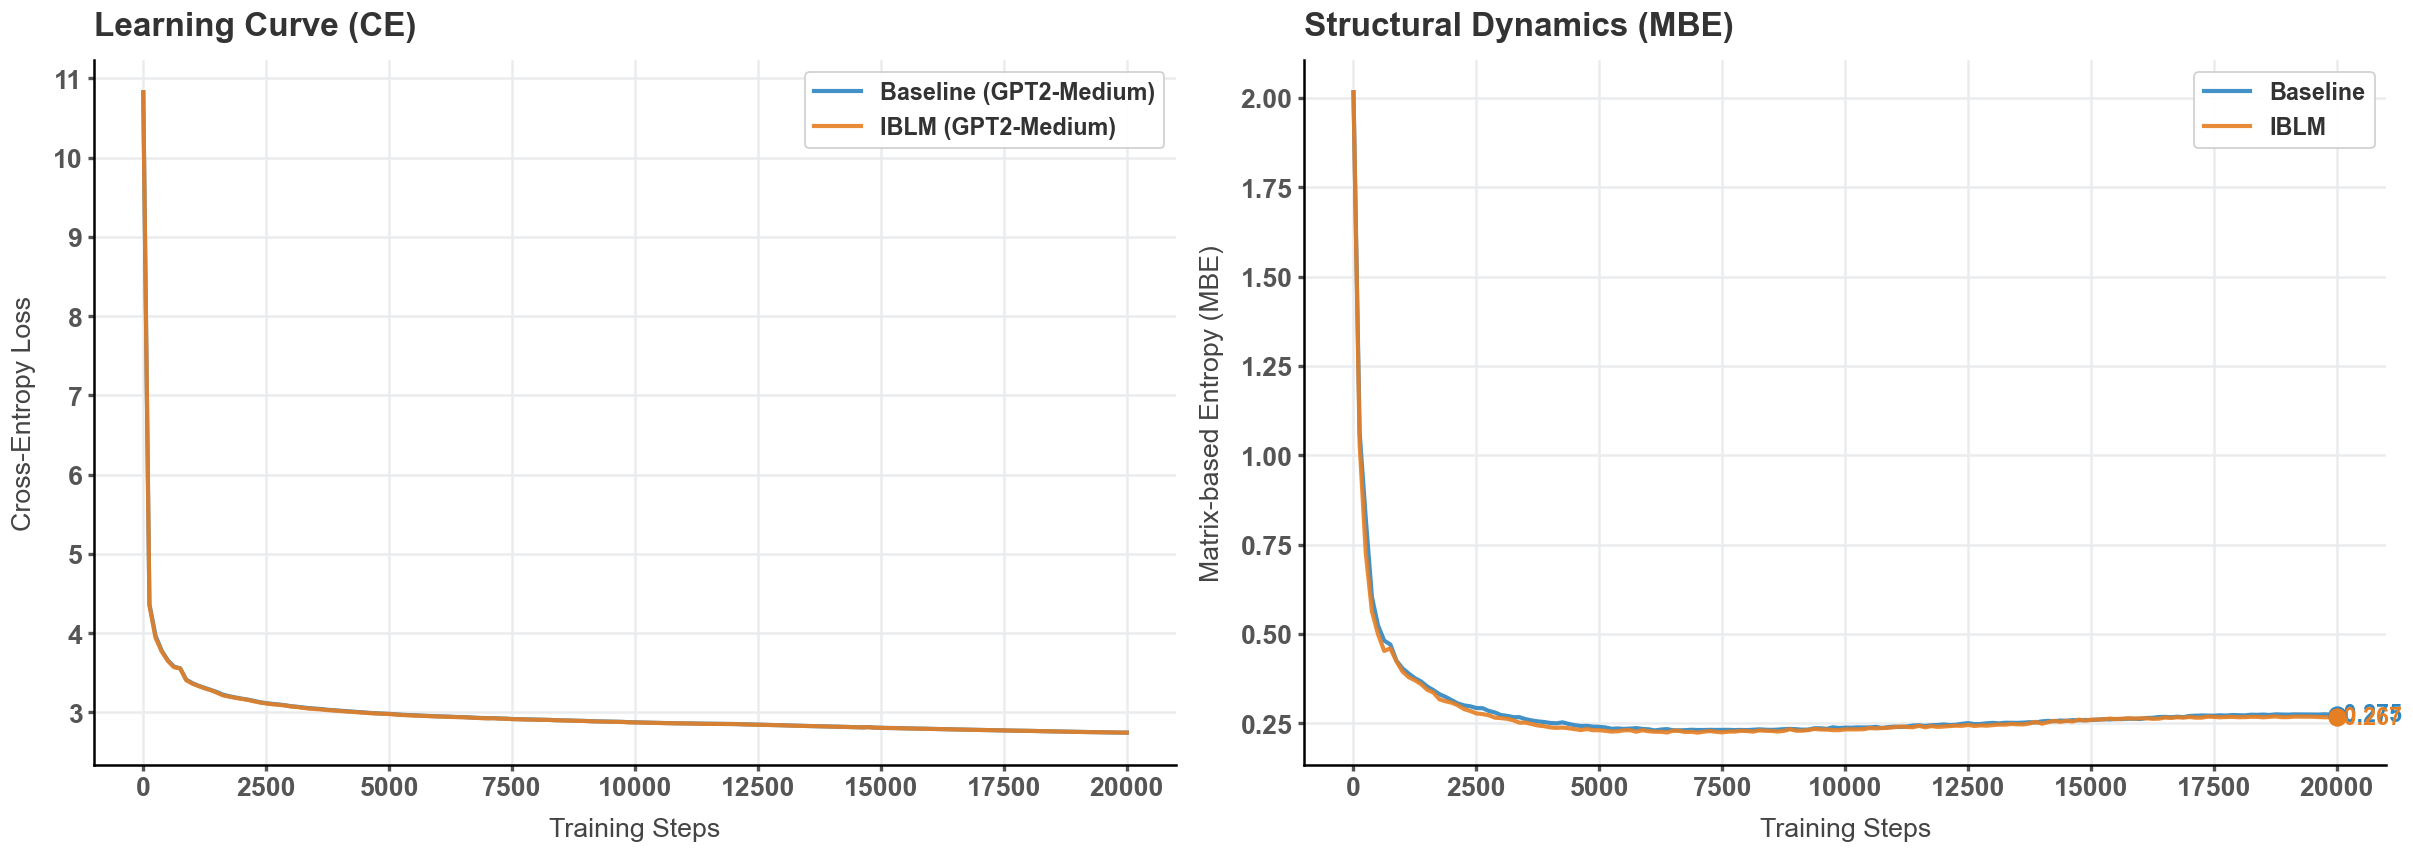

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Loading (assuming already loaded as per your snippet) ---
# _, gpt2_small_iblm_record = extract_log_data("logs/iblm-fineweb10B-gpt2-small-20k.txt")
# _, gpt2_small_record = extract_log_data("logs/fineweb10B-gpt2-small-20k.txt")

# Configuration
val_interval = 125
l = len(gpt2_small_record['entropy'])
steps_baseline = np.arange(l) * val_interval
steps_iblm = np.arange(l) * val_interval  # Truncate for plotting, must match baseline length

# --- Style Settings ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 1.5

# Colors
c_base = '#2E86C1'  # Strong Blue (Baseline)
c_iblm = '#E67E22'  # Strong Orange (IBLM)
c_grid = '#EAECEE'

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=120, constrained_layout=True)
fig.patch.set_facecolor('white')

# ============================================
# 1. Entropy Comparison (Performance)
# ============================================
ax1 = axes[0]
ax1.set_facecolor('white')
# Plot
ax1.plot(steps_baseline, gpt2_small_record['entropy'], label='Baseline (GPT2-Medium)', 
         color=c_base, linewidth=2.5, alpha=0.9)
ax1.plot(steps_iblm, gpt2_small_iblm_record['entropy'][:l], label='IBLM (GPT2-Medium)', 
         color=c_iblm, linewidth=2.5, alpha=0.9)

# Details
ax1.set_xlabel('Training Steps', fontsize=16, labelpad=10)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=16, labelpad=10)
ax1.set_title('Learning Curve (CE)', fontsize=20, fontweight='bold', loc='left', pad=15)
ax1.grid(True, color=c_grid, linestyle='-', linewidth=1.5)
ax1.legend(fontsize=14, frameon=True, framealpha=0.95, loc='upper right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ============================================
# 2. MBE Comparison (Structure)
# ============================================
ax2 = axes[1]
ax2.set_facecolor('white')

# Plot
ax2.plot(steps_baseline, gpt2_small_record['mbe'], label='Baseline', 
         color=c_base, linewidth=2.5, alpha=0.9)
ax2.plot(steps_iblm, gpt2_small_iblm_record['mbe'][:l], label='IBLM', 
         color=c_iblm, linewidth=2.5, alpha=0.9)

# Annotate Final Values
base_final = gpt2_small_record['mbe'][-1]
iblm_final = gpt2_small_iblm_record['mbe'][:l][-1]

ax2.scatter([steps_baseline[-1]], [base_final], color=c_base, s=100, zorder=5)
ax2.text(steps_baseline[-1], base_final, f' {base_final:.3f}', 
         color=c_base, va='center', fontweight='bold', fontsize=14)

ax2.scatter([steps_iblm[-1]], [iblm_final], color=c_iblm, s=100, zorder=5)
ax2.text(steps_iblm[-1], iblm_final, f' {iblm_final:.3f}', 
         color=c_iblm, va='center', fontweight='bold', fontsize=14)

# Details
ax2.set_xlabel('Training Steps', fontsize=16, labelpad=10)
ax2.set_ylabel('Matrix-based Entropy (MBE)', fontsize=16, labelpad=10)
ax2.set_title('Structural Dynamics (MBE)', fontsize=20, fontweight='bold', loc='left', pad=15)
ax2.grid(True, color=c_grid, linestyle='-', linewidth=1.5)
ax2.legend(fontsize=14, frameon=True, framealpha=0.95, loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.savefig('baseline_vs_iblm_comparison.png', bbox_inches='tight')
plt.show()

In [52]:
# gpt2_large_record["entropy"][-1]
gpt2_large_record["mbe"][-1]

0.2010226779513889

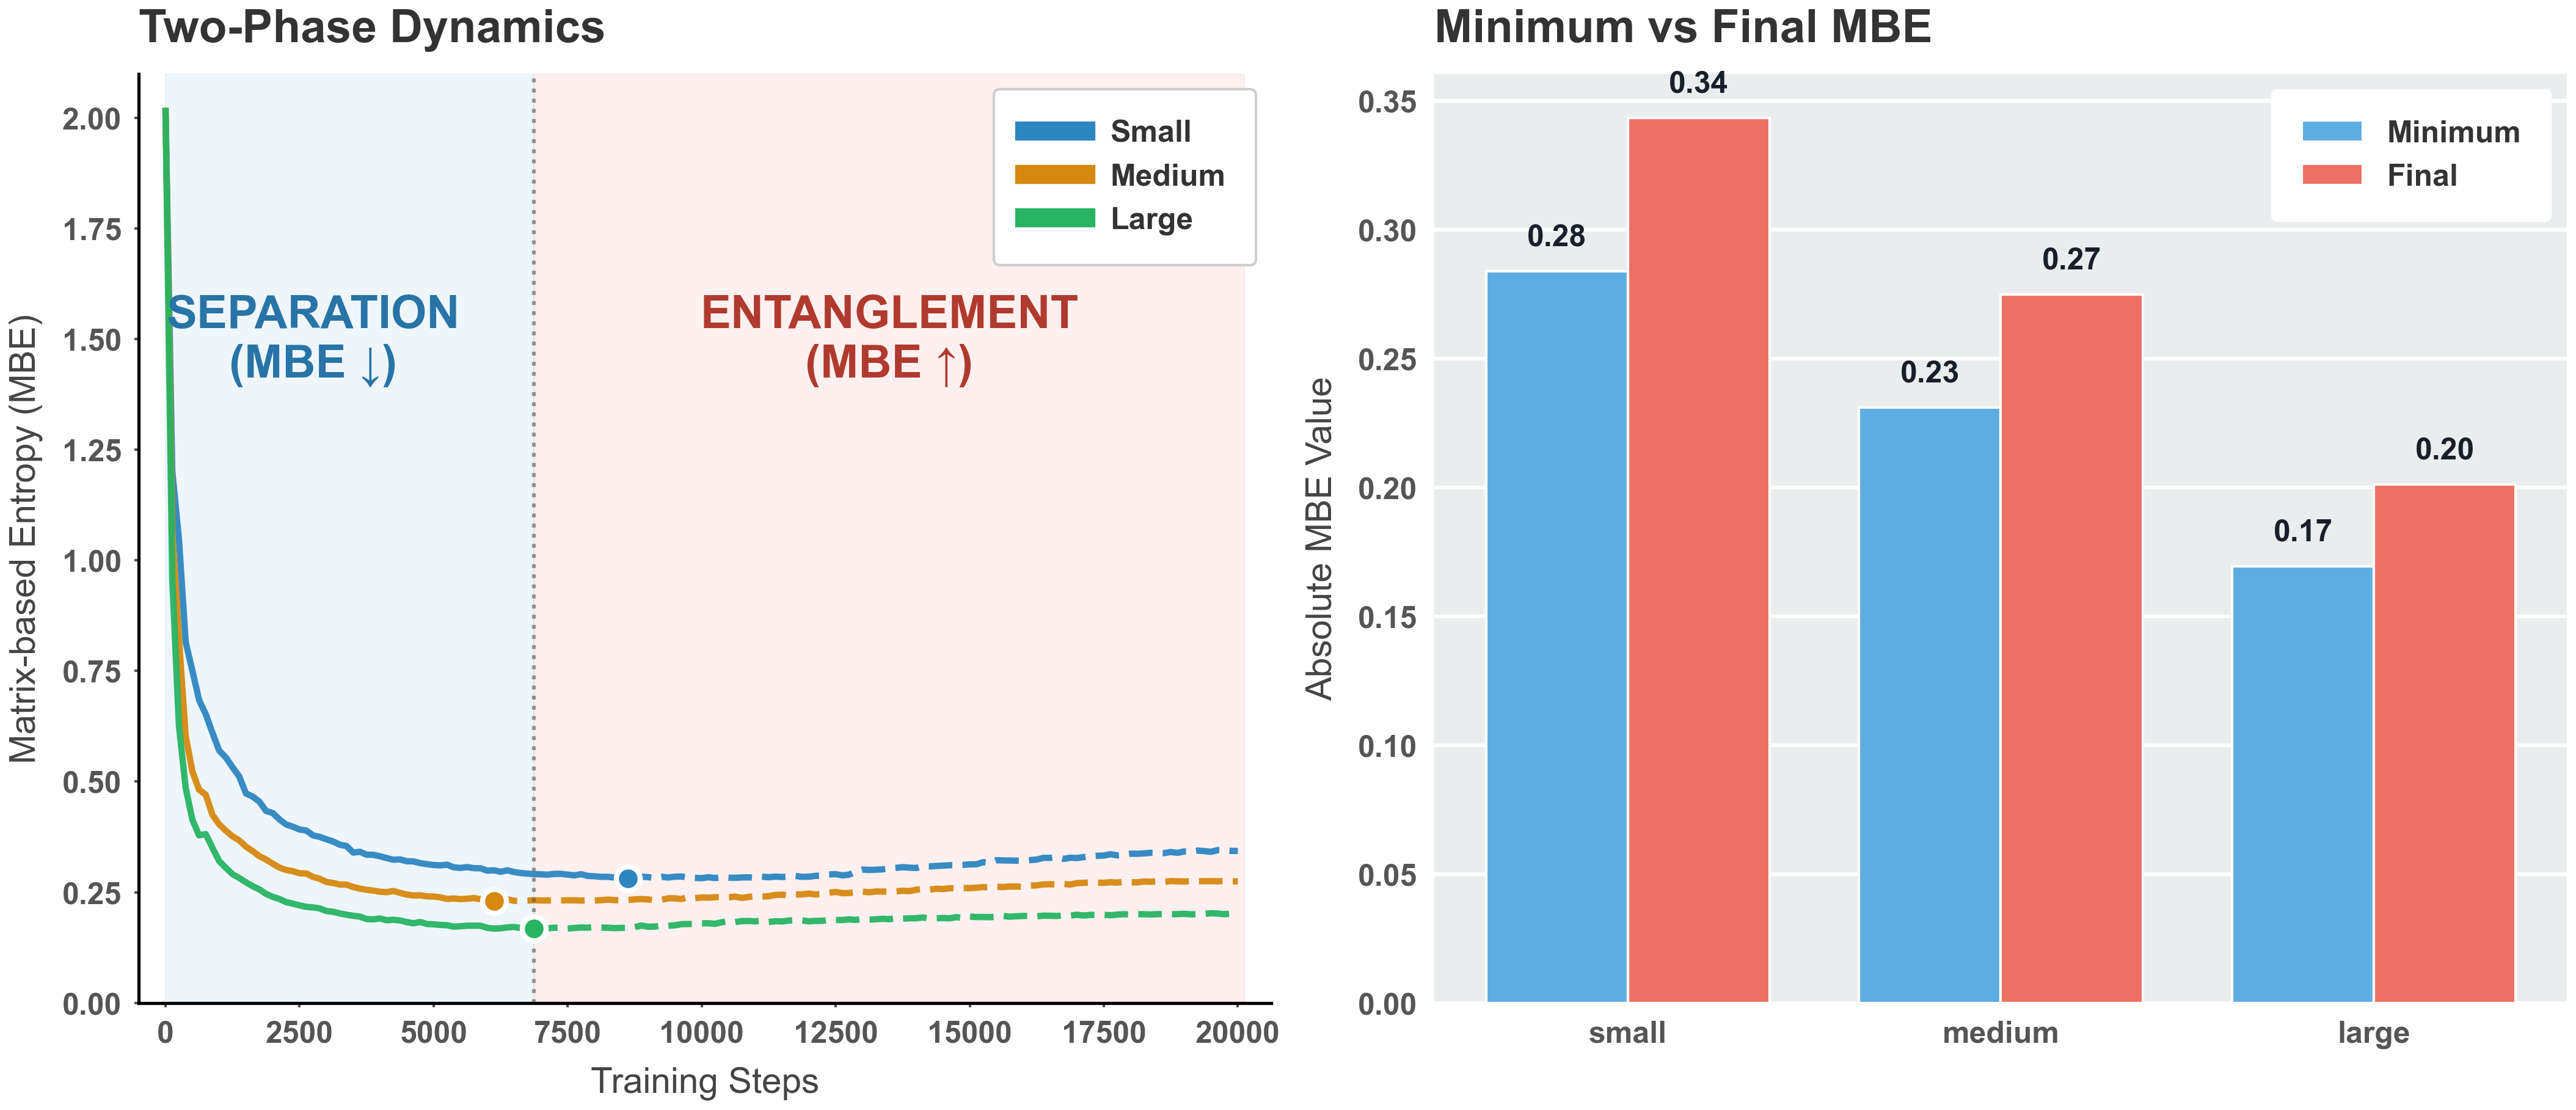

In [35]:
# ---- MBE dynamics plot ---
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

small_path = "logs/fineweb10B-gpt2-small-20k.txt"
_, gpt2_small_record = extract_log_data(small_path)

medium_path = "logs/fineweb10B-gpt2-medium-20k.txt"
_, gpt2_medium_record = extract_log_data(medium_path)

large_path = "logs/fineweb10B-gpt2-large-20k.txt"
_, gpt2_large_record = extract_log_data(large_path)

# --- Data ---
records = {
    'GPT2-small': gpt2_small_record,
    'GPT2-medium': gpt2_medium_record,
    'GPT2-large': gpt2_large_record,
}

val_interval = 125
models = ['GPT2-small', 'GPT2-medium', 'GPT2-large']
x = np.arange(len(models))
model_colors = ['#2E86C1', '#D68910', '#28B463'] # Stronger Blue, Orange, Green

c_sep = '#5DADE2' # Lighter blue for fill
c_ent = '#EC7063' # Lighter red for fill
c_gray = '#EAEDED'
c_text = '#17202A'

sep_mbe_end = [0.2838, 0.2310, 0.1694]
ent_mbe_end = [0.3433, 0.2747, 0.2010]

# --- SUPER-SIZE STYLE ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 24  # HUGE BASE FONT
plt.rcParams['axes.linewidth'] = 2.5 # Thicker axes
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(28, 12), dpi=150, constrained_layout=True)
fig.patch.set_facecolor('white')

# ============================================
# LEFT: MBE Trajectory
# ============================================
ax1 = axes[0]
ax1.set_facecolor('white')

all_mbe = [np.array(r['mbe']) for r in records.values()]
max_len = max(len(m) for m in all_mbe)
max_step = max_len * val_interval

# Plot Lines (Thicker)
for i, (model, record) in enumerate(records.items()):
    mbe = np.array(record['mbe'])
    steps = np.arange(len(mbe)) * val_interval
    min_idx = np.argmin(mbe)
    min_step = min_idx * val_interval
    min_val = mbe[min_idx]
    
    # Line width 5 for visibility
    ax1.plot(steps[:min_idx+1], mbe[:min_idx+1], linewidth=5, color=model_colors[i], alpha=0.95)
    ax1.plot(steps[min_idx:], mbe[min_idx:], linewidth=5, color=model_colors[i], alpha=0.95, linestyle='--')
    ax1.scatter([min_step], [min_val], s=350, color=model_colors[i], edgecolor='white', linewidth=4, zorder=5)

# Background Shading
large_mbe = np.array(records['GPT2-large']['mbe'])
transition_step = np.argmin(large_mbe) * val_interval
ax1.axvspan(0, transition_step, alpha=0.1, color=c_sep, zorder=0)
ax1.axvspan(transition_step, max_step, alpha=0.1, color=c_ent, zorder=0)
ax1.axvline(transition_step, color='#555555', linestyle=':', linewidth=3, alpha=0.6)

# Text Annotations (Massive)
ax1.text(transition_step * 0.4, 1.6, 'SEPARATION\n(MBE ↓)', 
         ha='center', va='top', fontsize=36, color='#2874A6', fontweight='heavy')
ax1.text(transition_step + (max_step - transition_step) * 0.5, 1.6, 'ENTANGLEMENT\n(MBE ↑)', 
         ha='center', va='top', fontsize=36, color='#B03A2E', fontweight='heavy')

# Legend
legend_elements = [
    Line2D([0], [0], color=model_colors[0], linewidth=15, label='Small'),
    Line2D([0], [0], color=model_colors[1], linewidth=15, label='Medium'),
    Line2D([0], [0], color=model_colors[2], linewidth=15, label='Large'),
]
# Simplified legend inside the plot
leg = ax1.legend(handles=legend_elements, loc='upper right', fontsize=24, frameon=True, framealpha=0.95, borderpad=1)
leg.get_frame().set_linewidth(2)

ax1.set_xlabel('Training Steps', fontsize=28, labelpad=15)
ax1.set_ylabel('Matrix-based Entropy (MBE)', fontsize=28, labelpad=15)
ax1.set_title('Two-Phase Dynamics', fontsize=36, pad=25, loc='left', fontweight='heavy')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(-500, max_step + 500)
ax1.set_ylim(0, 2.1)
ax1.tick_params(labelsize=24, pad=10)

# ============================================
# RIGHT: MBE Minimum vs Final
# ============================================
ax2 = axes[1]
ax2.set_facecolor(c_gray)
width_g = 0.38

rects1 = ax2.bar(x - width_g/2, sep_mbe_end, width_g, label='Minimum', color=c_sep, zorder=3, edgecolor='white', linewidth=2)
rects2 = ax2.bar(x + width_g/2, ent_mbe_end, width_g, label='Final', color=c_ent, zorder=3, edgecolor='white', linewidth=2)

ax2.grid(axis='y', color='white', linestyle='-', linewidth=3, zorder=0)
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace('GPT2-', '') for m in models], fontweight='bold', fontsize=28) # Shorten names
ax2.set_ylabel('Absolute MBE Value', fontsize=28, labelpad=15)
ax2.set_title('Minimum vs Final MBE', fontsize=36, pad=25, loc='left', fontweight='heavy')
leg2 = ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=1, fontsize=24, borderpad=1)
leg2.get_frame().set_linewidth(0)

for spine in ax2.spines.values(): spine.set_visible(False)
ax2.tick_params(left=False, bottom=False, labelsize=24, pad=10)

# Values on bars
for rect in rects1:
    h = rect.get_height()
    ax2.text(rect.get_x() + rect.get_width()/2., h + 0.01, f'{h:.2f}', ha='center', fontsize=24, fontweight='bold', color=c_text)
for rect in rects2:
    h = rect.get_height()
    ax2.text(rect.get_x() + rect.get_width()/2., h + 0.01, f'{h:.2f}', ha='center', fontsize=24, fontweight='bold', color=c_text)

# plt.suptitle('GPT-2: MBE Phase Dynamics Scaling Laws', fontsize=40, fontweight='heavy', color='#1a1a1a', y=1.05)

plt.savefig('mbe_presentation_quality.png', dpi=150, bbox_inches='tight')
plt.show()